# Netflix Movies and TV Shows Data Analysis

This notebook explores a Netflix movies and TV shows dataset from Kaggle. The objective is to clean the data, analyze content patterns, visualize trends, and build a simple content-based recommendation baseline.

Main questions:
- What are the most common genres?
- How are popularity and vote scores distributed?
- Which titles are the most popular or best rated?
- How does content release evolve over time?
- Can we recommend similar titles using metadata?

## 1. Setup

In [1]:
# If needed, run this once:
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn wordcloud

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
warnings.filterwarnings("ignore")

## 2. Load Dataset

The dataset contains a CSV file with a space in the filename. The loading function below is robust to malformed CSV rows, long text fields, and encoding issues.

In [2]:
import kagglehub

DATASET_SLUG = "nalisha/netflix-movies-and-tv-shows-data-analysis"

dataset_path = Path(kagglehub.dataset_download(DATASET_SLUG))
print("Dataset downloaded to:", dataset_path)

csv_files = list(dataset_path.rglob("*.csv"))
print("CSV files found:")
for file in csv_files:
    print("-", file)

assert len(csv_files) > 0, "No CSV file found in the dataset directory."
csv_path = csv_files[0]
print("\nSelected file:", csv_path)

Dataset downloaded to: /home/cli/.cache/kagglehub/datasets/nalisha/netflix-movies-and-tv-shows-data-analysis/versions/1
CSV files found:
- /home/cli/.cache/kagglehub/datasets/nalisha/netflix-movies-and-tv-shows-data-analysis/versions/1/mymoviedb (1).csv

Selected file: /home/cli/.cache/kagglehub/datasets/nalisha/netflix-movies-and-tv-shows-data-analysis/versions/1/mymoviedb (1).csv


In [22]:
df.shape
df.columns.tolist()
df.head()
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   release_date       9827 non-null   datetime64[ns]
 1   title              9837 non-null   object        
 2   overview           9837 non-null   object        
 3   popularity         9827 non-null   float64       
 4   vote_count         9826 non-null   float64       
 5   vote_average       9826 non-null   float64       
 6   original_language  9837 non-null   object        
 7   genre              9837 non-null   object        
 8   poster_url         9826 non-null   object        
 9   release_year       9827 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 768.6+ KB


release_date         10
title                 0
overview              0
popularity           10
vote_count           11
vote_average         11
original_language     0
genre                 0
poster_url           11
release_year         10
dtype: int64

In [23]:
df.shape
df["genre"].value_counts().head(10)
df["release_year"].value_counts().sort_index().tail(10)
df.sort_values("popularity", ascending=False)[["title", "genre", "popularity", "vote_average"]].head(10)
df.groupby("genre")["popularity"].mean().sort_values(ascending=False).head(10)
df["vote_average"].describe()
df["popularity"].describe()

count    9827.000000
mean       40.320570
std       108.874308
min         7.100000
25%        16.127500
50%        21.191000
75%        35.174500
max      5083.954000
Name: popularity, dtype: float64

In [24]:
genre_df = df.assign(genre=df["genre"].str.split(",")).explode("genre")
genre_df["genre"] = genre_df["genre"].str.strip()

print(genre_df["genre"].value_counts().head(10))
print(genre_df.groupby("genre")["popularity"].mean().sort_values(ascending=False).head(10))

genre
Drama        3744
Comedy       3031
Action       2686
Thriller     2488
Adventure    1853
Romance      1476
Horror       1470
Animation    1438
Family       1414
Fantasy      1308
Name: count, dtype: int64
genre
Adventure          53.742888
Fantasy            53.081342
Animation          52.427663
Action             50.890133
Science Fiction    49.511334
Family             46.610616
Crime              44.747295
Thriller           42.946258
Mystery            40.093590
Horror             38.264498
Name: popularity, dtype: float64


In [3]:
def read_csv_robust(path):
    """Read a CSV file with fallbacks for malformed lines and encoding issues."""
    attempts = [
        {"engine": "c", "encoding": "utf-8"},
        {"engine": "python", "encoding": "utf-8", "encoding_errors": "replace", "on_bad_lines": "warn"},
        {"engine": "python", "encoding": "latin1", "on_bad_lines": "warn"},
        {"engine": "python", "encoding": "utf-8", "encoding_errors": "replace", "on_bad_lines": "skip"},
    ]

    last_error = None
    for kwargs in attempts:
        try:
            print("Trying read_csv with:", kwargs)
            return pd.read_csv(path, **kwargs)
        except Exception as error:
            last_error = error
            print("Failed:", repr(error))

    raise last_error


df_raw = read_csv_robust(csv_path)
print("Shape:", df_raw.shape)
df_raw.head()

Trying read_csv with: {'engine': 'c', 'encoding': 'utf-8'}
Failed: ParserError('Error tokenizing data. C error: Buffer overflow caught - possible malformed input file.\n')
Trying read_csv with: {'engine': 'python', 'encoding': 'utf-8', 'encoding_errors': 'replace', 'on_bad_lines': 'warn'}
Shape: (9837, 9)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to separate his normal life from the high-stakes of being a super-hero. ...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4irTY1GPXvft6k4YLjm.jpg
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman uncovers corruption in Gotham City that connects to his own family whil...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R36Fpooo50r9T25onhq.jpg
2,2022-02-25,No Exit,"Stranded at a rest stop in the mountains during a blizzard, a recovering addict discovers a kidnapped child hidden i...",2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKlPGmWs0kGfuhNF4w5l.jpg
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madrigals, who live hidden in the mountains of Colombia, in a magical house...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5ax3IA8tjtxcmPU3QT.jpg
4,2021-12-22,The King's Man,"As a collection of history's worst tyrants and criminal masterminds gather to plot a war to wipe out millions, one m...",1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeuvj6HZKtxyd23e6bE9.jpg


## 3. Initial Inspection

In [4]:
print("Columns:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes)

print("\nMissing values:")
display(df_raw.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df_raw.duplicated().sum())

Columns:
['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count', 'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url']

Data types:


Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count            object
Vote_Average          object
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object


Missing values:


Genre                11
Poster_Url           11
Original_Language    10
Vote_Count           10
Popularity           10
Vote_Average         10
Title                 9
Overview              9
Release_Date          0
dtype: int64


Duplicate rows: 0


## 4. Data Cleaning

In [5]:
df = df_raw.copy()

# Normalize column names.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

# Remove useless index columns if present.
unnamed_cols = [col for col in df.columns if col.startswith("unnamed")]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# Drop exact duplicates.
df = df.drop_duplicates().reset_index(drop=True)

print("Cleaned columns:")
print(df.columns.tolist())
print("Shape after duplicate removal:", df.shape)
df.head()

Cleaned columns:
['release_date', 'title', 'overview', 'popularity', 'vote_count', 'vote_average', 'original_language', 'genre', 'poster_url']
Shape after duplicate removal: (9837, 9)


,release_date,title,overview,popularity,vote_count,vote_average,original_language,genre,poster_url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to separate his normal life from the high-stakes of being a super-hero. ...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4irTY1GPXvft6k4YLjm.jpg
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman uncovers corruption in Gotham City that connects to his own family whil...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R36Fpooo50r9T25onhq.jpg
2,2022-02-25,No Exit,"Stranded at a rest stop in the mountains during a blizzard, a recovering addict discovers a kidnapped child hidden i...",2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKlPGmWs0kGfuhNF4w5l.jpg
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madrigals, who live hidden in the mountains of Colombia, in a magical house...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5ax3IA8tjtxcmPU3QT.jpg
4,2021-12-22,The King's Man,"As a collection of history's worst tyrants and criminal masterminds gather to plot a war to wipe out millions, one m...",1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeuvj6HZKtxyd23e6bE9.jpg


In [6]:
# Helper function to find a column even if the exact dataset schema changes slightly.
def find_col(candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


title_col = find_col(["title", "name", "movie_name"])
genre_col = find_col(["genre", "genres", "listed_in"])
date_col = find_col(["release_date", "date_added"])
year_col = find_col(["release_year", "year"])
popularity_col = find_col(["popularity", "popular"])
vote_avg_col = find_col(["vote_average", "vote_avg", "rating", "score"])
vote_count_col = find_col(["vote_count", "votes"])
overview_col = find_col(["overview", "description", "summary"])
language_col = find_col(["original_language", "language"])

columns_map = {
    "title_col": title_col,
    "genre_col": genre_col,
    "date_col": date_col,
    "year_col": year_col,
    "popularity_col": popularity_col,
    "vote_avg_col": vote_avg_col,
    "vote_count_col": vote_count_col,
    "overview_col": overview_col,
    "language_col": language_col,
}

columns_map

{'title_col': 'title',
 'genre_col': 'genre',
 'date_col': 'release_date',
 'year_col': None,
 'popularity_col': 'popularity',
 'vote_avg_col': 'vote_average',
 'vote_count_col': 'vote_count',
 'overview_col': 'overview',
 'language_col': 'original_language'}

In [7]:
# Convert dates and create release_year if possible.
if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    if "release_year" not in df.columns:
        df["release_year"] = df[date_col].dt.year
        year_col = "release_year"

# Numeric conversions.
for col in [popularity_col, vote_avg_col, vote_count_col, year_col]:
    if col is not None and col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Text cleanup.
for col in [title_col, genre_col, overview_col, language_col]:
    if col is not None and col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   release_date       9827 non-null   datetime64[ns]
 1   title              9837 non-null   object        
 2   overview           9837 non-null   object        
 3   popularity         9827 non-null   float64       
 4   vote_count         9826 non-null   float64       
 5   vote_average       9826 non-null   float64       
 6   original_language  9837 non-null   object        
 7   genre              9837 non-null   object        
 8   poster_url         9826 non-null   object        
 9   release_year       9827 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 768.6+ KB


## 5. Descriptive Statistics

In [8]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
release_date,9827,NaN,NaN,NaN,2006-09-23 11:05:51.317797888,1902-04-17 00:00:00,2000-10-18 00:00:00,2011-09-13 00:00:00,2017-11-22 00:00:00,2024-07-03 00:00:00,NaN
title,9837,9514,Unknown,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overview,9837,9824,Unknown,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,9827.0,NaN,NaN,NaN,40.32057,7.1,16.1275,21.191,35.1745,5083.954,108.874308
vote_count,9826.0,NaN,NaN,NaN,1392.943721,0.0,146.0,444.0,1376.0,31077.0,2611.303856
vote_average,9826.0,NaN,NaN,NaN,6.439467,0.0,5.9,6.5,7.1,10.0,1.129797
original_language,9837,45,en,7569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,9837,2338,Drama,466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poster_url,9826,9826,https://image.tmdb.org/t/p/original/lBhU4U9Eehr9shstPem6I7BdkxK.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,9827.0,NaN,NaN,NaN,2006.203623,1902.0,2000.0,2011.0,2017.0,2024.0,15.685554


In [9]:
if title_col is not None:
    print("Number of unique titles:", df[title_col].nunique())

if year_col is not None:
    print("Release year range:", int(df[year_col].min()), "-", int(df[year_col].max()))

if genre_col is not None:
    print("Number of unique raw genre labels:", df[genre_col].nunique())

Number of unique titles: 9514
Release year range: 1902 - 2024
Number of unique raw genre labels: 2338


## 6. Genre Analysis

In [10]:
def split_genres(value):
    if pd.isna(value):
        return ["Unknown"]
    value = str(value)
    # Some datasets use comma-separated genres; others may use pipe-separated genres.
    value = value.replace("|", ",")
    return [item.strip() for item in value.split(",") if item.strip()]


if genre_col is not None:
    genre_df = df.copy()
    genre_df["genre_clean"] = genre_df[genre_col].apply(split_genres)
    genre_df = genre_df.explode("genre_clean")
    genre_df["genre_clean"] = genre_df["genre_clean"].fillna("Unknown")
    display(genre_df[[title_col, genre_col, "genre_clean"]].head(10) if title_col else genre_df[[genre_col, "genre_clean"]].head(10))
else:
    genre_df = None
    print("No genre column found.")

,title,genre,genre_clean
0,Spider-Man: No Way Home,"Action, Adventure, Science Fiction",Action
0,Spider-Man: No Way Home,"Action, Adventure, Science Fiction",Adventure
0,Spider-Man: No Way Home,"Action, Adventure, Science Fiction",Science Fiction
1,The Batman,"Crime, Mystery, Thriller",Crime
1,The Batman,"Crime, Mystery, Thriller",Mystery
1,The Batman,"Crime, Mystery, Thriller",Thriller
2,No Exit,Thriller,Thriller
3,Encanto,"Animation, Comedy, Family, Fantasy",Animation
3,Encanto,"Animation, Comedy, Family, Fantasy",Comedy
3,Encanto,"Animation, Comedy, Family, Fantasy",Family


genre_clean
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Name: count, dtype: int64

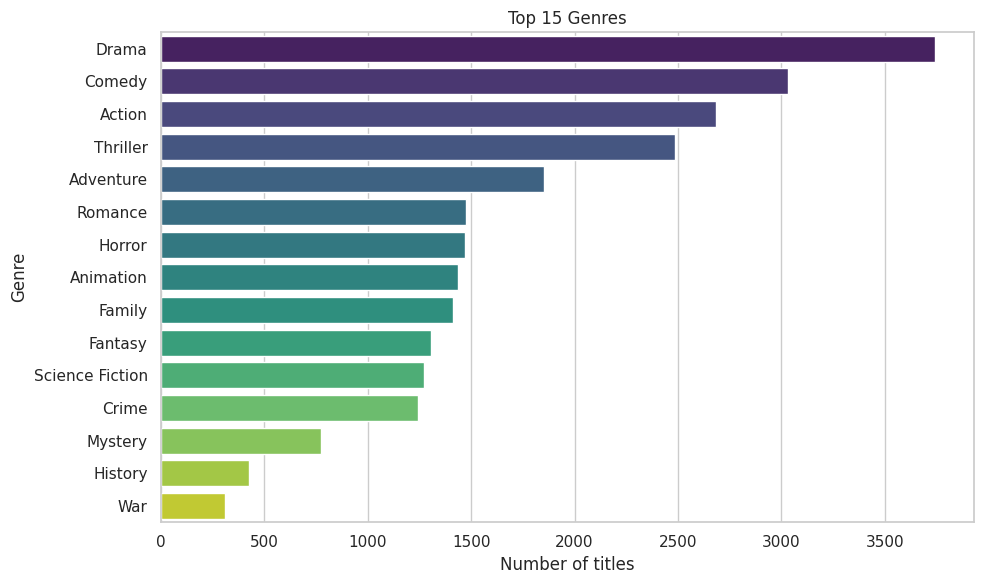

In [11]:
if genre_df is not None:
    top_genres = genre_df["genre_clean"].value_counts().head(15)
    display(top_genres)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
    plt.title("Top 15 Genres")
    plt.xlabel("Number of titles")
    plt.ylabel("Genre")
    plt.tight_layout()
    plt.show()

## 7. Popularity and Rating Analysis

,count,mean,std,min,25%,50%,75%,max
popularity,9827.0,40.320570,108.874308,7.1,16.1275,21.191,35.1745,5083.954
vote_average,9826.0,6.439467,1.129797,0.0,5.9000,6.500,7.1000,10.000
vote_count,9826.0,1392.943721,2611.303856,0.0,146.0000,444.000,1376.0000,31077.000


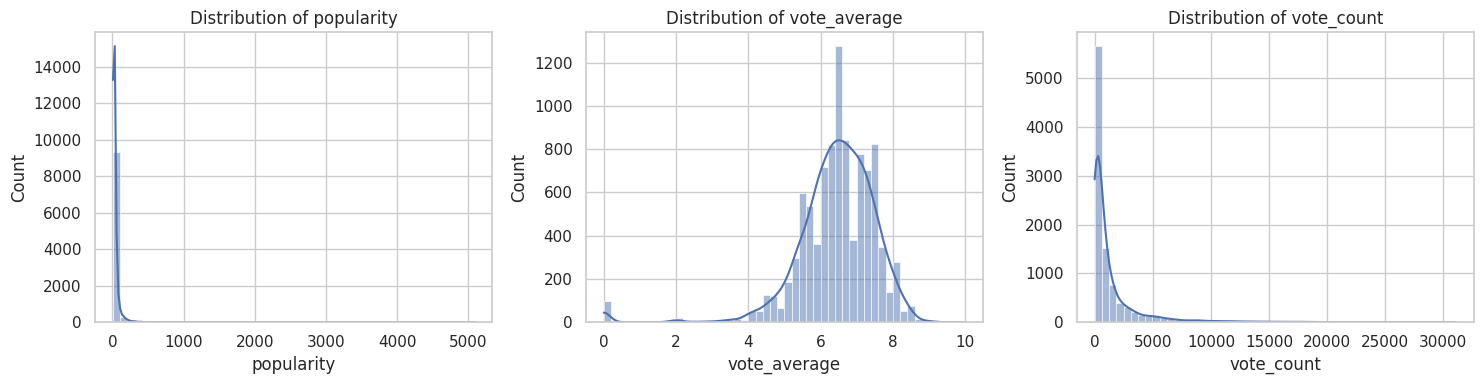

In [12]:
numeric_cols = [col for col in [popularity_col, vote_avg_col, vote_count_col] if col is not None]
if numeric_cols:
    display(df[numeric_cols].describe().T)

    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        sns.histplot(df[col].dropna(), bins=50, kde=True, ax=ax)
        ax.set_title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric popularity or rating columns found.")

In [13]:
if title_col is not None and popularity_col is not None:
    cols = [title_col]
    for col in [genre_col, popularity_col, vote_avg_col, vote_count_col, year_col, language_col]:
        if col is not None and col not in cols:
            cols.append(col)

    print("Most popular titles:")
    display(df.sort_values(popularity_col, ascending=False)[cols].head(15))

Most popular titles:


,title,genre,popularity,vote_average,vote_count,release_year,original_language
0,Spider-Man: No Way Home,"Action, Adventure, Science Fiction",5083.954,8.3,8940.0,2021.0,en
1,The Batman,"Crime, Mystery, Thriller",3827.658,8.1,1151.0,2022.0,en
2,No Exit,Thriller,2618.087,6.3,122.0,2022.0,en
3,Encanto,"Animation, Comedy, Family, Fantasy",2402.201,7.7,5076.0,2021.0,en
4,The King's Man,"Action, Adventure, Thriller, War",1895.511,7.0,1793.0,2021.0,en
5,The Commando,"Action, Crime, Thriller",1750.484,6.6,33.0,2022.0,en
6,Scream,"Horror, Mystery, Thriller",1675.161,6.8,821.0,2022.0,en
7,Kimi,Thriller,1601.782,6.3,206.0,2022.0,en
8,Fistful of Vengeance,"Action, Crime, Fantasy",1594.013,5.3,114.0,2022.0,en
9,Eternals,Science Fiction,1537.406,7.2,4726.0,2021.0,en


In [14]:
if title_col is not None and vote_avg_col is not None:
    cols = [title_col]
    for col in [genre_col, vote_avg_col, vote_count_col, popularity_col, year_col]:
        if col is not None and col not in cols:
            cols.append(col)

    rating_df = df.copy()
    if vote_count_col is not None:
        # Avoid titles with high score but very few votes.
        min_votes = rating_df[vote_count_col].quantile(0.75)
        rating_df = rating_df[rating_df[vote_count_col] >= min_votes]
        print("Minimum vote count threshold:", min_votes)

    print("Top rated titles among sufficiently voted content:")
    display(rating_df.sort_values(vote_avg_col, ascending=False)[cols].head(15))

Minimum vote count threshold: 1376.0
Top rated titles among sufficiently voted content:


,title,genre,vote_average,vote_count,popularity,release_year
657,The Shawshank Redemption,"Drama, Crime",8.7,20911.0,87.669,1994.0
3156,Dilwale Dulhania Le Jayenge,"Comedy, Drama, Romance",8.7,3474.0,29.087,1995.0
609,The Godfather,"Drama, Crime",8.7,15614.0,93.136,1972.0
1327,Schindler's List,"Drama, History, War",8.6,12474.0,55.225,1993.0
1007,The Godfather: Part II,"Drama, Crime",8.6,9393.0,65.324,1974.0
1769,GoodFellas,"Drama, Crime",8.5,9860.0,44.572,1990.0
2519,12 Angry Men,Drama,8.5,6227.0,34.638,1957.0
480,Parasite,"Comedy, Thriller, Drama",8.5,13240.0,108.442,2019.0
221,The Dark Knight,"Drama, Action, Crime, Thriller",8.5,26994.0,173.923,2008.0
3631,Seven Samurai,"Action, Drama",8.5,2580.0,26.328,1954.0


## 8. Trends Over Time

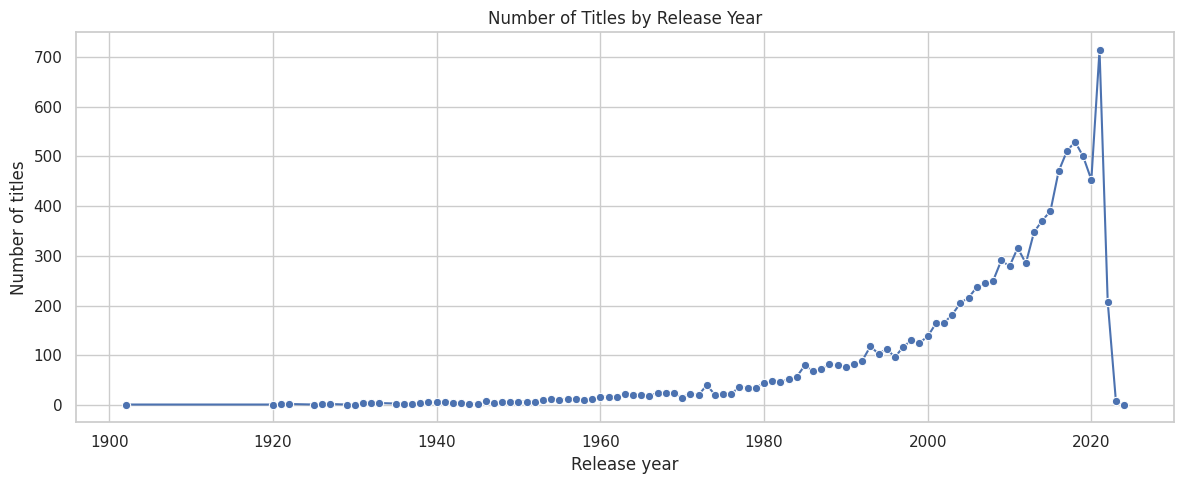

release_year
2005    216
2006    237
2007    245
2008    250
2009    291
2010    279
2011    316
2012    285
2013    348
2014    371
2015    390
2016    470
2017    510
2018    530
2019    500
2020    453
2021    714
2022    208
2023      8
2024      1
Name: count, dtype: int64

In [15]:
if year_col is not None:
    year_counts = df[year_col].dropna().astype(int).value_counts().sort_index()

    plt.figure(figsize=(12, 5))
    sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")
    plt.title("Number of Titles by Release Year")
    plt.xlabel("Release year")
    plt.ylabel("Number of titles")
    plt.tight_layout()
    plt.show()

    display(year_counts.tail(20))
else:
    print("No release year column found.")

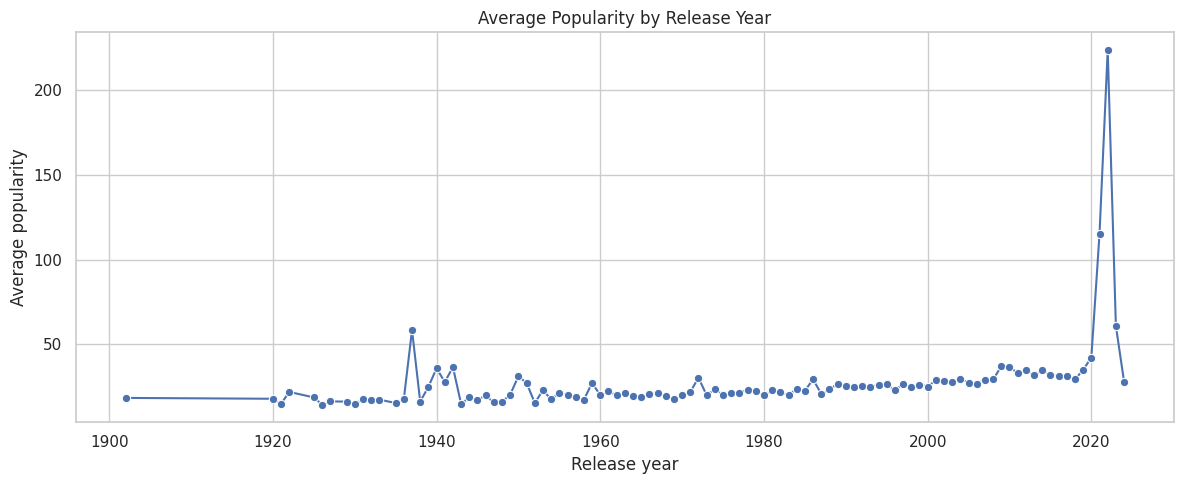

In [16]:
if year_col is not None and popularity_col is not None:
    yearly_popularity = (
        df.dropna(subset=[year_col, popularity_col])
        .groupby(year_col)[popularity_col]
        .mean()
        .sort_index()
    )

    plt.figure(figsize=(12, 5))
    sns.lineplot(x=yearly_popularity.index, y=yearly_popularity.values, marker="o")
    plt.title("Average Popularity by Release Year")
    plt.xlabel("Release year")
    plt.ylabel("Average popularity")
    plt.tight_layout()
    plt.show()

## 9. Language Analysis

original_language
en    7569
ja     645
es     339
fr     292
ko     170
zh     129
it     123
cn     109
ru      83
de      82
pt      37
da      28
hi      26
no      26
sv      23
Name: count, dtype: int64

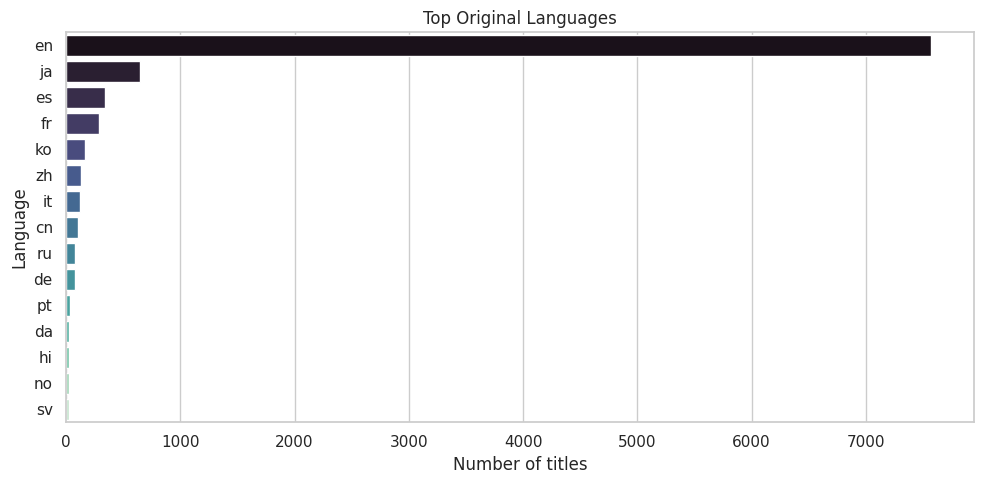

In [17]:
if language_col is not None:
    top_languages = df[language_col].value_counts().head(15)
    display(top_languages)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_languages.values, y=top_languages.index, palette="mako")
    plt.title("Top Original Languages")
    plt.xlabel("Number of titles")
    plt.ylabel("Language")
    plt.tight_layout()
    plt.show()
else:
    print("No language column found.")

## 10. Genre Quality and Popularity Comparison

,n_titles,avg_popularity
genre_clean,,
Adventure,1853,53.742888
Fantasy,1308,53.081342
Animation,1438,52.427663
Action,2686,50.890133
Science Fiction,1273,49.511334
Family,1414,46.610616
Crime,1242,44.747295
Thriller,2488,42.946258
Mystery,773,40.093590


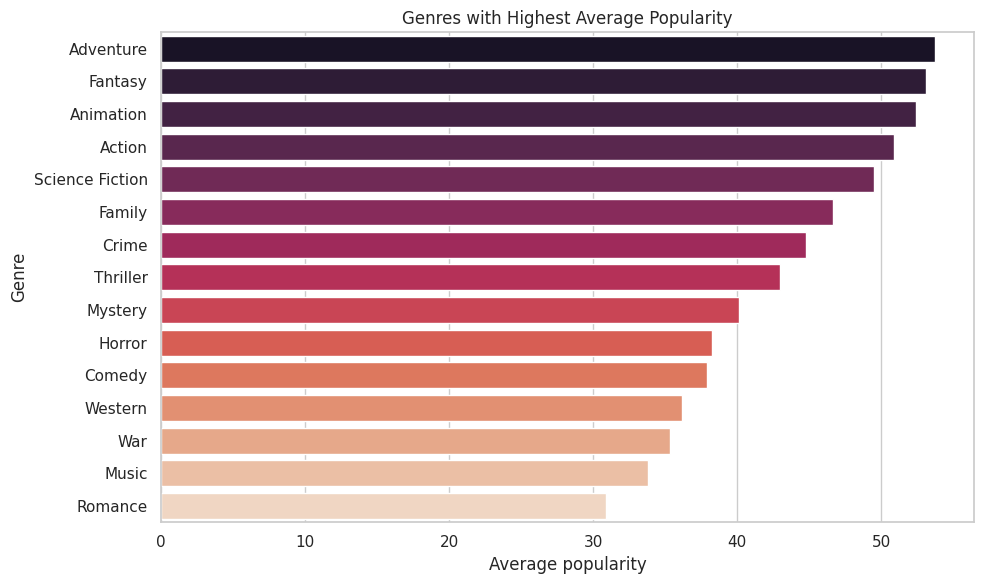

,n_titles,avg_rating
genre_clean,,
History,427,6.965574
War,308,6.948701
Music,295,6.879322
Animation,1438,6.846384
Western,137,6.754745
Drama,3744,6.706143
Documentary,215,6.663721
Family,1414,6.581047
Romance,1476,6.560772


In [18]:
if genre_df is not None and popularity_col is not None:
    genre_popularity = (
        genre_df.groupby("genre_clean")
        .agg(
            n_titles=("genre_clean", "size"),
            avg_popularity=(popularity_col, "mean"),
        )
        .query("n_titles >= 20")
        .sort_values("avg_popularity", ascending=False)
        .head(15)
    )
    display(genre_popularity)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=genre_popularity.reset_index(), x="avg_popularity", y="genre_clean", palette="rocket")
    plt.title("Genres with Highest Average Popularity")
    plt.xlabel("Average popularity")
    plt.ylabel("Genre")
    plt.tight_layout()
    plt.show()

if genre_df is not None and vote_avg_col is not None:
    genre_rating = (
        genre_df.groupby("genre_clean")
        .agg(
            n_titles=("genre_clean", "size"),
            avg_rating=(vote_avg_col, "mean"),
        )
        .query("n_titles >= 20")
        .sort_values("avg_rating", ascending=False)
        .head(15)
    )
    display(genre_rating)

## 11. Simple Content-Based Recommendation System

This baseline recommends titles with similar metadata and descriptions. It uses TF-IDF features and cosine similarity.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

text_cols = []
for col in [title_col, genre_col, overview_col, language_col]:
    if col is not None and col in df.columns:
        text_cols.append(col)

print("Text columns used for recommendation:", text_cols)

assert title_col is not None, "A title column is required for recommendation."
assert len(text_cols) > 0, "No text columns available for recommendation."

rec_df = df.dropna(subset=[title_col]).copy().reset_index(drop=True)
rec_df["content_text"] = rec_df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

tfidf = TfidfVectorizer(stop_words="english", max_features=10000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(rec_df["content_text"])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("TF-IDF matrix shape:", tfidf_matrix.shape)

Text columns used for recommendation: ['title', 'genre', 'overview', 'original_language']
TF-IDF matrix shape: (9837, 10000)


In [20]:
def recommend_titles(title, top_n=10):
    """Return titles that are most similar to the input title."""
    title_lower = title.lower().strip()
    matches = rec_df[rec_df[title_col].str.lower().str.contains(title_lower, na=False)]

    if matches.empty:
        return pd.DataFrame({"message": [f"No title found for query: {title}"]})

    idx = matches.index[0]
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)[1:top_n + 1]

    result_indices = [i for i, score in similarity_scores]
    result = rec_df.loc[result_indices].copy()
    result["similarity"] = [score for i, score in similarity_scores]

    output_cols = [title_col, "similarity"]
    for col in [genre_col, overview_col, popularity_col, vote_avg_col, year_col, language_col]:
        if col is not None and col in result.columns and col not in output_cols:
            output_cols.append(col)

    return result[output_cols]


# Example: change the title according to titles available in the dataset.
sample_title = rec_df[title_col].iloc[0]
print("Sample query title:", sample_title)
recommend_titles(sample_title, top_n=10)

Sample query title: Spider-Man: No Way Home


,title,similarity,genre,overview,popularity,vote_average,release_year,original_language
170,Spider-Man,0.484585,"Fantasy, Action","After being bitten by a genetically altered spider at Oscorp, nerdy but endearing high school student Peter Parker i...",206.376,7.2,2002.0,en
1500,Spider-Man,0.445661,"Science Fiction, Action, Crime, TV Movie","When an extortionist threatens to force a multi-suicide unless a huge ransom is paid, only Peter Parker can stop him...",50.753,5.5,1977.0,en
201,Spider-Man 3,0.429841,"Fantasy, Action, Adventure",The seemingly invincible Spider-Man goes up against an all-new crop of villains—including the shape-shifting Sandman...,186.125,6.3,2007.0,en
191,Spider-Man: Into the Spider-Verse,0.417466,"Action, Adventure, Animation, Science Fiction","Miles Morales is juggling his life between being a high school student and being a spider-man. When Wilson ""Kingpin""...",190.775,8.4,2018.0,en
4067,Spider-Man Strikes Back,0.408149,"Action, Adventure, Family, Fantasy, TV Movie","At the New York State University, one of Peter Parker's tutors has accidentally given three students all the materia...",24.244,5.2,1978.0,en
7949,Beyond the Ultimate Spin: The Making of 'Spider-Man',0.399026,Documentary,Documentary on the making of 'Spider-Man.',15.325,3.5,2002.0,en
2652,Spider-Man 2: Making the Amazing,0.385861,"Action, Adventure, Science Fiction, Documentary","A comprehensive 12-part documentary on the making of ""Spider-Man 2,"" covering everything from pre-production to prem...",33.298,7.0,2004.0,en
144,Spider-Man: Far From Home,0.379224,"Action, Adventure, Science Fiction","Peter Parker and his friends go on a summer trip to Europe. However, they will hardly be able to rest - Peter will h...",224.034,7.5,2019.0,en
168,Spider-Man: Homecoming,0.378626,"Action, Adventure, Science Fiction, Drama","Following the events of Captain America: Civil War, Peter Parker, with the help of his mentor Tony Stark, tries to b...",207.817,7.4,2017.0,en
1373,Spider-Man 2,0.351894,"Action, Adventure, Fantasy","Peter Parker is going through a major identity crisis. Burned out from being Spider-Man, he decides to shelve his su...",53.750,7.2,2004.0,en


## 12. Optional: Popularity Prediction Baseline

If a popularity column is available, we can build a simple baseline model. The goal is not to achieve production-level accuracy, but to show a reproducible ML workflow.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

if popularity_col is not None:
    model_df = df.copy()
    feature_candidates = [year_col, vote_avg_col, vote_count_col, language_col, genre_col]
    feature_cols = [col for col in feature_candidates if col is not None and col in model_df.columns and col != popularity_col]

    model_df = model_df.dropna(subset=[popularity_col])
    X = model_df[feature_cols]
    y = model_df[popularity_col]

    numeric_features = [col for col in feature_cols if pd.api.types.is_numeric_dtype(X[col])]
    categorical_features = [col for col in feature_cols if col not in numeric_features]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print("Features:", feature_cols)
    print("MAE:", round(mean_absolute_error(y_test, preds), 4))
    print("R2:", round(r2_score(y_test, preds), 4))
else:
    print("No popularity column found. Skipping ML baseline.")

Features: ['release_year', 'vote_average', 'vote_count', 'original_language', 'genre']
MAE: 23.2183
R2: 0.2318


## 13. Key Insights

Possible conclusions to write after running the notebook:

1. The catalog is concentrated around a limited set of dominant genres.
2. Popularity is highly skewed: a small number of titles receive much higher attention than the majority.
3. Vote average and popularity are not the same signal: some titles can be highly rated without being the most popular.
4. Release-year trends reveal how the catalog evolves across time.
5. A simple TF-IDF recommender already produces reasonable metadata-based recommendations, but it does not model user behavior.

Limitations:
- The dataset is static and may not represent the current Netflix catalog.
- Popularity and rating metrics may come from external sources and may be biased by audience size.
- The recommendation system is content-based only; it does not use user interaction data.